In [36]:
#LIBRARIES IMPORT & LOAD DATASET
import pandas as pd
import numpy as np
print("Libraries loaded successfully!")

df = pd.read_csv('daily_food_delivery_orders.csv')
print("Dataset loaded!")
print(df.head())

Libraries loaded successfully!
Dataset loaded!
   order_id  order_date  customer_age restaurant_type  order_value  \
0         1  2024-11-05            62          Indian       497.51   
1         2  2024-08-20            35          Bakery       232.32   
2         3  2024-02-28            34         Italian       540.82   
3         4  2024-05-26            65            Cafe      1197.99   
4         5  2024-09-21            40          Indian       947.03   

   delivery_distance_km  delivery_time_minutes payment_method  \
0                 11.07                     79            UPI   
1                  5.83                     69         Wallet   
2                  3.61                     70         Wallet   
3                  3.66                     18           Card   
4                 12.08                     57            UPI   

   delivery_partner_rating order_status  
0                      3.9    Cancelled  
1                      2.7    Cancelled  
2              

In [37]:
#DATA CLEANIING!!!
#DATASET INFO & DATATYPES CHECK
print("Dataset Shape:")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print("\nColumn Names:")
print(df.columns.tolist())

print("Data Types:")
print(df.dtypes)

Dataset Shape:
Rows: 2600
Columns: 10

Column Names:
['order_id', 'order_date', 'customer_age', 'restaurant_type', 'order_value', 'delivery_distance_km', 'delivery_time_minutes', 'payment_method', 'delivery_partner_rating', 'order_status']
Data Types:
order_id                     int64
order_date                  object
customer_age                 int64
restaurant_type             object
order_value                float64
delivery_distance_km       float64
delivery_time_minutes        int64
payment_method              object
delivery_partner_rating    float64
order_status                object
dtype: object


In [38]:
#MISSING VALUES & DUPLICATE VALUES CHECK
print("Missing Values:")
missing = df.isnull().sum()
print(missing)
print(f"\nTotal missing: {missing.sum()}")

duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

if duplicates == 0:
    print("✅ No duplicates! Dataset is clean!")
else:
    print(f"⚠️ {duplicates} duplicates found")
    df = df.drop_duplicates()

Missing Values:
order_id                   0
order_date                 0
customer_age               0
restaurant_type            0
order_value                0
delivery_distance_km       0
delivery_time_minutes      0
payment_method             0
delivery_partner_rating    0
order_status               0
dtype: int64

Total missing: 0
Duplicate rows: 0
✅ No duplicates! Dataset is clean!


In [39]:
#FIXING DATATYPE
print("Before fixing date:")
print(df['order_date'].dtype)

# Convert to datetime
df['order_date'] = pd.to_datetime(df['order_date'])
print("\nAfter fixing date:")
print(df['order_date'].dtype)

print("\nSample dates:")
print(df['order_date'].head())

Before fixing date:
object

After fixing date:
datetime64[ns]

Sample dates:
0   2024-11-05
1   2024-08-20
2   2024-02-28
3   2024-05-26
4   2024-09-21
Name: order_date, dtype: datetime64[ns]


In [40]:
#CHECKING INVALID/NEGATIVE VALUES
print("Checking for negative/invalid values:\n")

print(f"Negative order_value: {(df['order_value'] < 0).sum()}")
print(f"Negative delivery_distance: {(df['delivery_distance_km'] < 0).sum()}")
print(f"Negative delivery_time: {(df['delivery_time_minutes'] < 0).sum()}")
print(f"Negative customer_age: {(df['customer_age'] < 0).sum()}")

print("\n✅ All values are positive and valid!")

Checking for negative/invalid values:

Negative order_value: 0
Negative delivery_distance: 0
Negative delivery_time: 0
Negative customer_age: 0

✅ All values are positive and valid!


In [41]:
#CHECKING DATA RANGES
print("Data Ranges:\n")

print(f"Customer Age: {df['customer_age'].min()} - {df['customer_age'].max()}")
print(f"Order Value: ₹{df['order_value'].min():.2f} - ₹{df['order_value'].max():.2f}")
print(f"Delivery Time: {df['delivery_time_minutes'].min()} - {df['delivery_time_minutes'].max()} min")
print(f"Delivery Distance: {df['delivery_distance_km'].min():.2f} - {df['delivery_distance_km'].max():.2f} km")
print(f"Delivery Rating: {df['delivery_partner_rating'].min()} - {df['delivery_partner_rating'].max()}")

print("\n✅ All ranges are realistic!")

Data Ranges:

Customer Age: 18 - 65
Order Value: ₹150.90 - ₹1199.78
Delivery Time: 15 - 90 min
Delivery Distance: 0.50 - 14.99 km
Delivery Rating: 2.5 - 5.0

✅ All ranges are realistic!


In [42]:
#CHECKING CATEGORY VALUES
print("Unique Values in Categories:\n")

print("Restaurant Types:")
print(df['restaurant_type'].unique())
print(f"Count: {df['restaurant_type'].nunique()}\n")

print("Payment Methods:")
print(df['payment_method'].unique())
print(f"Count: {df['payment_method'].nunique()}\n")

print("Order Status:")
print(df['order_status'].unique())
print(f"Count: {df['order_status'].nunique()}")

print("\n✅ All categories are consistent!")

Unique Values in Categories:

Restaurant Types:
['Indian' 'Bakery' 'Italian' 'Cafe' 'Chinese' 'Fast Food']
Count: 6

Payment Methods:
['UPI' 'Wallet' 'Card' 'Cash']
Count: 4

Order Status:
['Cancelled' 'Delayed' 'Delivered']
Count: 3

✅ All categories are consistent!


In [43]:
#FINAL SUMMARY
print("="*50)
print("DATA CLEANING COMPLETE!")
print("="*50)

print(f"\n✅ Total Orders: {len(df):,}")
print(f"✅ Total Columns: {len(df.columns)}")
print(f"✅ Missing Values: {df.isnull().sum().sum()}")
print(f"✅ Duplicate Rows: {df.duplicated().sum()}")
print(f"✅ Invalid Values: 0")

print(f"\n💰 Financial Summary:")
print(f"   Total Revenue: ₹{df['order_value'].sum():,.0f}")
print(f"   Avg Order: ₹{df['order_value'].mean():.0f}")

print(f"\n🍽️ Categories:")
print(f"   Restaurant Types: {df['restaurant_type'].nunique()}")
print(f"   Payment Methods: {df['payment_method'].nunique()}")
print(f"   Order Status: {df['order_status'].nunique()}")

print(f"\n✅ DATASET IS CLEAN AND READY!")
print("="*50)

DATA CLEANING COMPLETE!

✅ Total Orders: 2,600
✅ Total Columns: 10
✅ Missing Values: 0
✅ Duplicate Rows: 0
✅ Invalid Values: 0

💰 Financial Summary:
   Total Revenue: ₹1,742,764
   Avg Order: ₹670

🍽️ Categories:
   Restaurant Types: 6
   Payment Methods: 4
   Order Status: 3

✅ DATASET IS CLEAN AND READY!


In [44]:
#SAVE CLEANED DATA
df.to_csv('food_delivery_cleaned.csv', index=False)

print("✅ Cleaned data saved as 'food_delivery_cleaned.csv'")
print("Ready to download!")

✅ Cleaned data saved as 'food_delivery_cleaned.csv'
Ready to download!


In [45]:
#DOWNLOAD CLEANED DATA
from google.colab import files

print("Downloading cleaned data file...")
files.download('food_delivery_cleaned.csv')
print("\n✅ Download started! Check your Downloads folder!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Download started! Check your Downloads folder!


In [46]:
#DATA PREPROCESSING!!!
#QUICK CHECK THE CLEANED DATASET READY OR NOT
print("Checking our cleaned dataset is ready:")
print(f"Total orders: {len(df)}")
print(df.head())

Checking our cleaned dataset is ready:
Total orders: 2600
   order_id order_date  customer_age restaurant_type  order_value  \
0         1 2024-11-05            62          Indian       497.51   
1         2 2024-08-20            35          Bakery       232.32   
2         3 2024-02-28            34         Italian       540.82   
3         4 2024-05-26            65            Cafe      1197.99   
4         5 2024-09-21            40          Indian       947.03   

   delivery_distance_km  delivery_time_minutes payment_method  \
0                 11.07                     79            UPI   
1                  5.83                     69         Wallet   
2                  3.61                     70         Wallet   
3                  3.66                     18           Card   
4                 12.08                     57            UPI   

   delivery_partner_rating order_status  
0                      3.9    Cancelled  
1                      2.7    Cancelled  
2         

In [47]:
#MONTH & DAY OF WEEK EXTRACT
df['order_month'] = df['order_date'].dt.month
print(df[['order_date', 'order_month']].head())

df['order_dayofweek'] = df['order_date'].dt.day_name()
print(df[['order_date', 'order_dayofweek']].head())

  order_date  order_month
0 2024-11-05           11
1 2024-08-20            8
2 2024-02-28            2
3 2024-05-26            5
4 2024-09-21            9
  order_date order_dayofweek
0 2024-11-05         Tuesday
1 2024-08-20         Tuesday
2 2024-02-28       Wednesday
3 2024-05-26          Sunday
4 2024-09-21        Saturday


In [48]:
#CREATING AGE GROUP
def age_group(age):
    if age < 30:
        return 'Young (18-29)'
    elif age < 45:
        return 'Adult (30-44)'
    else:
        return 'Senior (45+)'

df['age_group'] = df['customer_age'].apply(age_group)

print(df[['customer_age', 'age_group']].head())
print(df['age_group'].value_counts())

   customer_age      age_group
0            62   Senior (45+)
1            35  Adult (30-44)
2            34  Adult (30-44)
3            65   Senior (45+)
4            40  Adult (30-44)
age_group
Senior (45+)     1138
Adult (30-44)     784
Young (18-29)     678
Name: count, dtype: int64


In [49]:
#DELIVERY SPEED CATEGORY
def delivery_speed(minutes):
    if minutes < 30:
        return 'Fast'
    elif minutes < 60:
        return 'Normal'
    else:
        return 'Slow'

df['delivery_speed'] = df['delivery_time_minutes'].apply(delivery_speed)

print(df[['delivery_time_minutes', 'delivery_speed']].head())
print(df['delivery_speed'].value_counts())

   delivery_time_minutes delivery_speed
0                     79           Slow
1                     69           Slow
2                     70           Slow
3                     18           Fast
4                     57         Normal
delivery_speed
Slow      1026
Normal    1026
Fast       548
Name: count, dtype: int64


In [50]:
#DISTANCE CATEGORY
def distance_category(km):
    if km < 5:
        return 'Near'
    elif km < 10:
        return 'Medium'
    else:
        return 'Far'

df['distance_category'] = df['delivery_distance_km'].apply(distance_category)

print(df[['delivery_distance_km', 'distance_category']].head())
print(df['distance_category'].value_counts())

   delivery_distance_km distance_category
0                 11.07               Far
1                  5.83            Medium
2                  3.61              Near
3                  3.66              Near
4                 12.08               Far
distance_category
Far       934
Medium    881
Near      785
Name: count, dtype: int64


In [51]:
#ORDER SIZE CATEGORY
def order_size(value):
    if value < 450:
        return 'Budget'
    elif value < 850:
        return 'Regular'
    else:
        return 'Premium'

df['order_size'] = df['order_value'].apply(order_size)

print(df[['order_value', 'order_size']].head())
print(df['order_size'].value_counts())

   order_value order_size
0       497.51    Regular
1       232.32     Budget
2       540.82    Regular
3      1197.99    Premium
4       947.03    Premium
order_size
Regular    1006
Premium     850
Budget      744
Name: count, dtype: int64


In [52]:
#CHECKING ALL NEW COLUMNS
print("All columns now:")
print(df.columns.tolist())

print("\nNew columns sample:")
print(df[['order_month', 'order_dayofweek', 'age_group',
          'delivery_speed', 'distance_category', 'order_size']].head())

All columns now:
['order_id', 'order_date', 'customer_age', 'restaurant_type', 'order_value', 'delivery_distance_km', 'delivery_time_minutes', 'payment_method', 'delivery_partner_rating', 'order_status', 'order_month', 'order_dayofweek', 'age_group', 'delivery_speed', 'distance_category', 'order_size']

New columns sample:
   order_month order_dayofweek      age_group delivery_speed  \
0           11         Tuesday   Senior (45+)           Slow   
1            8         Tuesday  Adult (30-44)           Slow   
2            2       Wednesday  Adult (30-44)           Slow   
3            5          Sunday   Senior (45+)           Fast   
4            9        Saturday  Adult (30-44)         Normal   

  distance_category order_size  
0               Far    Regular  
1            Medium     Budget  
2              Near    Regular  
3              Near    Premium  
4               Far    Premium  


In [53]:
#SAVE PREPROCESSED DATA
df.to_csv('food_delivery_processed.csv', index=False)

print("✅ Saved as 'food_delivery_processed.csv'")
print(f"Total rows: {len(df)}, Total columns: {len(df.columns)}")

✅ Saved as 'food_delivery_processed.csv'
Total rows: 2600, Total columns: 16


In [54]:
#DOWNLOAD PREPROCESSED DATA
from google.colab import files

files.download('food_delivery_processed.csv')
print("✅ Download started! Check Downloads folder!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download started! Check Downloads folder!


In [55]:
#BASIC ANALYSIS!!!
#QUICK CHECK THE PREPROCESSED DATA READY OR NOT
print("Our processed data:")
print(f"Total orders: {len(df)}")
print(df.columns.tolist())

Our processed data:
Total orders: 2600
['order_id', 'order_date', 'customer_age', 'restaurant_type', 'order_value', 'delivery_distance_km', 'delivery_time_minutes', 'payment_method', 'delivery_partner_rating', 'order_status', 'order_month', 'order_dayofweek', 'age_group', 'delivery_speed', 'distance_category', 'order_size']


In [56]:
#KEY NUMBERS
print("KEY NUMBERS:\n")
print(f"Total Orders: {len(df)}")
print(f"Total Revenue: ₹{df['order_value'].sum():,.0f}")
print(f"Average Order Value: ₹{df['order_value'].mean():.0f}")
print(f"Average Delivery Time: {df['delivery_time_minutes'].mean():.0f} minutes")

KEY NUMBERS:

Total Orders: 2600
Total Revenue: ₹1,742,764
Average Order Value: ₹670
Average Delivery Time: 52 minutes


In [57]:
#CATEGORY-WISE SALES
category_sales = df.groupby('restaurant_type')['order_value'].sum().sort_values(ascending=False)

print("Sales by Restaurant Type:")
print(category_sales)

Sales by Restaurant Type:
restaurant_type
Bakery       307868.44
Cafe         295853.44
Chinese      288504.21
Fast Food    287299.50
Indian       282462.33
Italian      280776.15
Name: order_value, dtype: float64


In [58]:
#MONTHLY SALES TREAND
monthly_sales = df.groupby('order_month')['order_value'].sum()

print("Sales by Month:")
print(monthly_sales)

print(f"\nBest Month: Month {monthly_sales.idxmax()} (₹{monthly_sales.max():,.0f})")

Sales by Month:
order_month
1     132542.80
2     137884.76
3     151553.64
4     124465.15
5     160907.54
6     145264.39
7     133742.67
8     163370.81
9     142089.01
10    159467.28
11    154824.54
12    136651.48
Name: order_value, dtype: float64

Best Month: Month 8 (₹163,371)


In [59]:
#PAYMENT METHOD ANALYSIS
payment_analysis = df['payment_method'].value_counts()

print("Payment Method Usage:")
print(payment_analysis)

Payment Method Usage:
payment_method
UPI       660
Wallet    658
Cash      648
Card      634
Name: count, dtype: int64


In [60]:
#AGE GROUP ANALYSIS
age_analysis = df.groupby('age_group')['order_value'].agg(['count', 'mean', 'sum'])

print("Age Group Analysis:")
print(age_analysis.round(0))

Age Group Analysis:
               count   mean       sum
age_group                            
Adult (30-44)    784  672.0  526537.0
Senior (45+)    1138  673.0  765606.0
Young (18-29)    678  665.0  450620.0


In [61]:
#ORDER STATUS ANALYSIS
status_counts = df['order_status'].value_counts()
status_pct = (df['order_status'].value_counts(normalize=True) * 100).round(1)

print("Order Status:")
print(status_counts)
print("\nPercentage:")
print(status_pct)

Order Status:
order_status
Delivered    895
Cancelled    873
Delayed      832
Name: count, dtype: int64

Percentage:
order_status
Delivered    34.4
Cancelled    33.6
Delayed      32.0
Name: proportion, dtype: float64


In [62]:
#AVERAGE DELIVERY TIME BY CATEGORY
delivery_by_category = df.groupby('restaurant_type')['delivery_time_minutes'].mean().sort_values()

print("Average Delivery Time by Category:")
print(delivery_by_category.round(0))

Average Delivery Time by Category:
restaurant_type
Italian      51.0
Fast Food    51.0
Chinese      52.0
Cafe         52.0
Bakery       52.0
Indian       53.0
Name: delivery_time_minutes, dtype: float64


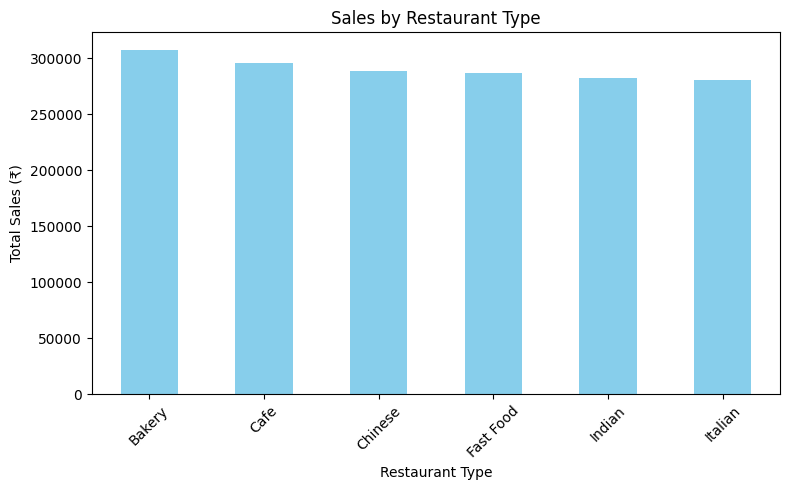

In [63]:
#CATEGORY SALES BAR CHART
import matplotlib.pyplot as plt

category_sales.plot(kind='bar', color='skyblue', figsize=(8,5))
plt.title('Sales by Restaurant Type')
plt.ylabel('Total Sales (₹)')
plt.xlabel('Restaurant Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('category_sales_chart.png')
plt.show()

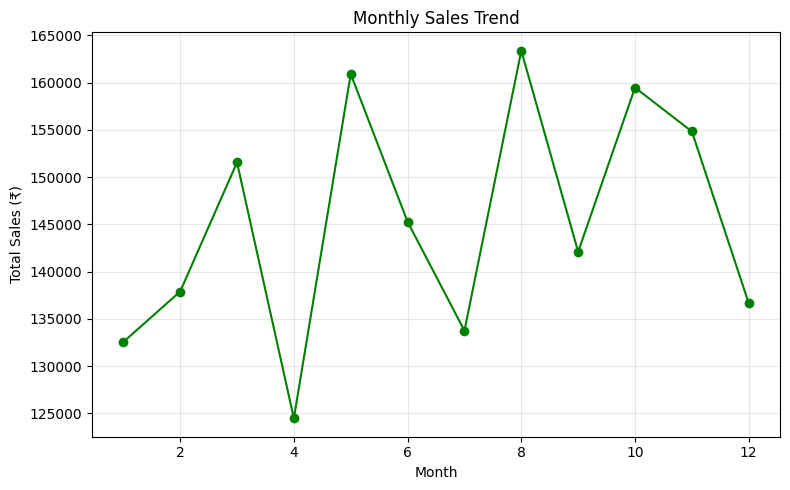

In [64]:
#MONTHLY TREND LINE CHART
monthly_sales.plot(kind='line', marker='o', color='green', figsize=(8,5))
plt.title('Monthly Sales Trend')
plt.ylabel('Total Sales (₹)')
plt.xlabel('Month')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('monthly_trend_chart.png')
plt.show()

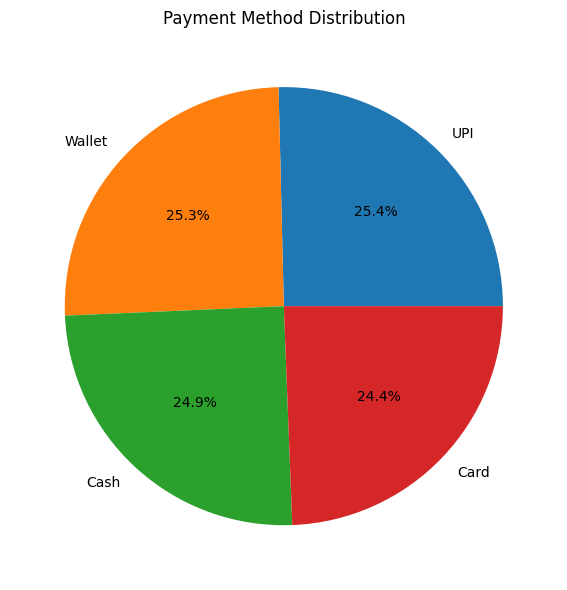

In [65]:
#PAYMENT METHOD PIE CHART
payment_analysis.plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))
plt.title('Payment Method Distribution')
plt.ylabel('')
plt.tight_layout()
plt.savefig('payment_pie_chart.png')
plt.show()

In [66]:
#FINAL SUMMARY
print("="*50)
print("BASIC ANALYSIS - KEY FINDINGS")
print("="*50)

print(f"\n1. Top Category: {category_sales.index[0]} (₹{category_sales.iloc[0]:,.0f})")
print(f"2. Best Month: Month {monthly_sales.idxmax()} (₹{monthly_sales.max():,.0f})")
print(f"3. Popular Payment: {payment_analysis.index[0]} ({payment_analysis.iloc[0]} orders)")
print(f"4. Most Active Age Group: {age_analysis['count'].idxmax()}")
print(f"5. Delivery Success: {status_pct['Delivered']:.1f}% delivered, {status_pct['Cancelled']:.1f}% cancelled")

BASIC ANALYSIS - KEY FINDINGS

1. Top Category: Bakery (₹307,868)
2. Best Month: Month 8 (₹163,371)
3. Popular Payment: UPI (660 orders)
4. Most Active Age Group: Senior (45+)
5. Delivery Success: 34.4% delivered, 33.6% cancelled
